Code to read in Kelly's base TF catalogue, and convert it to a clustering catalogue by cross-matching with the BGS clustering catalogue, attaching weights and then returning a subset of the columns

In [1]:
import fitsio
import numpy as np
import pandas as pd
import healpy as hp
from astropy.io import fits
from astropy.table import Table, vstack
import matplotlib.pyplot as plt
from sklearn.neighbors import KDTree
from astropy.cosmology import FlatLambdaCDM
import matplotlib.colors as colors

LightSpeed = 299792.458
nside = 16
zmin = 0.01        # minimum redshift for selection
zmax = 0.1         # maximum redshift for selection
rfact = 20         # size of final random catalogue relative to data
ngrid = 128        # grid size for number density
nzbin = 36         # number of redshift bins for plotting
rsets = 18         # number of DESI random catalogues to use
survey_area = 12378.1064 * (np.pi/180.0)**2
cosmo = FlatLambdaCDM(H0=100,Om0=0.3151)
deccel = 3.0*0.3151/2.0 - 1.0
version = 4
stem = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/'

In [2]:
# Useful utilities
def radec2thphi(ra,dec):
    return (-dec+90.)*np.pi/180.,ra*np.pi/180.
    
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def weighted_avg_and_std(values, weights, axis=None):
    average = np.average(values, weights=weights, axis=axis)
    average_err = np.std(values)*np.sqrt(np.sum((weights/np.sum(weights))**2))
    variance = np.average((values-average)**2, weights=weights, axis=axis)
    return (average, average_err, np.sqrt(variance))

# Heliocentric to CMB frame conversion routine from Anthony Carr.
def perform_corr(z_inp, RA, Dec, corrtype="full", dipole="Planck"):

    """
    A function to perform heliocentric corrections on redshifts.

    
    Inputs
    ======
    
    z_inp : float
        input heliocentric or CMB frame redshift
    
    RA : float
        equatorial right ascension
    
    Dec : float
        equatorial declination
    
    corrtype : string
        The type of correction to be performed. Either 'full' (default), 
        'approx',
        
        '-full' or '-approx', respectively corresponding to the proper 
        correction, low-z additive approximation, and the backwards corrections 
        to go from z_CMB to z_helio.
    
    dipole : string
        'Planck', 'COBE' or 'Astropy' dipoles. 'Astropy' imports astropy (slow) 
        and uses their co-ordinates and transforms and COBE dipole; different 
        beyond first decimal point.

    
    Outputs
    =======
    
    z_CMB : float
        (if corrtype is 'full' or 'approx')
    
    z_helio : float
        (only if corrtype is '-full' or '-approx')


    Notes
    =====
    
    Co-ords of North Galactic Pole (ICRS): 
        RA = 192.729 ± 0.035 deg, Dec = 27.084 ± 0.023 deg 
        (https://doi.org/10.1093/mnras/stw2772)
    
    Co-ords of Galactic Centre (ICRS): 
        RA = 17h45m40.0409s, Dec = −29d00m28.118s (see above reference)
        RA = 266.41683708 deg, Dec = -29.00781056 deg
    
    Ascending node of the galactic plane 
        = arccos(sin(Dec_GC)*cos(Dec_NGP)-cos(Dec_GC)*sin(Dec_NGP)*cos(RA_NGP-RA_GC))
        = 122.92828126730255 
        = l_0
    
    Transform CMB dipole from (l,b) to (RA,Dec):
        Dec = arcsin(sin(Dec_NGP)*sin(b)+cos(Dec_NGP)*cos(b)*cos(l_0-l))
            = -6.9895105228347 deg
        RA = RA_NGP + arctan((cos(b)*sin(l_0-l)) / (cos(Dec_NGP)*sin(b)-sin(Dec_NGP)*cos(b)*cos(l_0-l)))
            = 167.81671014708002 deg
    
    Astropy co-ordinates:
        RA_NGP_J2000 = 192.8594812065348, Dec_NGP_J2000 = 27.12825118085622, which are converted from B1950
        RA_NGP_B1950 = 192.25, Dec_NGP_B1950 = 27.4
        l_0_B1950 = 123
        l_0_J2000 = 122.9319185680026
    """

    v_Sun_Planck = 369.82  # +/- 0.11 km/s
    l_dipole_Planck = 264.021  # +/- 0.011 deg
    b_dipole_Planck = 48.253  # +/- 0.005 deg
    c = 299792.458  # km/s
    v_Sun_COBE = 371.0
    l_dipole_COBE = 264.14
    b_dipole_COBE = 48.26

    RA_Sun_Planck = 167.81671014708002  # deg
    Dec_Sun_Planck = -6.9895105228347
    RA_Sun_COBE = 167.88112630619747  # deg
    Dec_Sun_COBE = -7.024553155965497

    # RA_Sun_COBE = 168.01187366045565  # deg using Astropy values     # 168.0118667
    # Dec_Sun_COBE = -6.983037861854297  # # # -6.98303424

    if corrtype not in ["full", "approx", "-full", "-approx"]:
        print("Correction type unknown.")
        raise ValueError

    rad = np.pi / 180.0
    if dipole == "Planck":
        # Vincenty formula
        alpha = np.arctan2(
            np.hypot(
                np.cos(Dec_Sun_Planck * rad) * np.sin(np.fabs(RA - RA_Sun_Planck) * rad),
                np.cos(Dec * rad) * np.sin(Dec_Sun_Planck * rad)
                - np.sin(Dec * rad)
                * np.cos(Dec_Sun_Planck * rad)
                * np.cos(np.fabs(RA - RA_Sun_Planck) * rad),
            ),
            np.sin(Dec * rad) * np.sin(Dec_Sun_Planck * rad)
            + np.cos(Dec * rad)
            * np.cos(Dec_Sun_Planck * rad)
            * np.cos(np.fabs((RA - RA_Sun_Planck)) * rad),
        )
    elif dipole == "COBE":
        alpha = np.arctan2(
            np.hypot(
                np.cos(Dec_Sun_COBE * rad) * np.sin(np.fabs(RA - RA_Sun_COBE) * rad),
                np.cos(Dec * rad) * np.sin(Dec_Sun_COBE * rad)
                - np.sin(Dec * rad)
                * np.cos(Dec_Sun_COBE * rad)
                * np.cos(np.fabs(RA - RA_Sun_COBE) * rad),
            ),
            np.sin(Dec * rad) * np.sin(Dec_Sun_COBE * rad)
            + np.cos(Dec * rad)
            * np.cos(Dec_Sun_COBE * rad)
            * np.cos(np.fabs((RA - RA_Sun_COBE)) * rad),
        )
    elif dipole == "astropy":
        coord_helio_COBE = SkyCoord(l_dipole_COBE * u.degree, 
                                    b_dipole_COBE * u.degree, 
                                    frame="galactic").galactic
        coord = SkyCoord(RA * u.degree, Dec * u.degree, frame="icrs").galactic
        alpha = coord_helio_COBE.separation(coord).radian
    
    if dipole == "Planck":
        v_Sun_proj = v_Sun_Planck * np.cos(alpha)
    elif dipole in ["COBE", "astropy"]:
        v_Sun_proj = v_Sun_COBE * np.cos(alpha)

    # z_Sun = -v_Sun_proj / c
    # Full special rel. correction since it is a peculiar vel
    #z_Sun = np.sqrt((1.0 + (-v_Sun_proj) / c) / (1.0 - (-v_Sun_proj) / c)) - 1.0
    z_Sun = -v_Sun_proj/c

    min_z = 0.0
    if corrtype == "full":
        z_CMB = np.where(z_inp <= min_z, z_inp, (1 + z_inp) / (1 + z_Sun) - 1)
    elif (corrtype == "-full"):
        # backwards correction where z_CMB is actually z_helio and vice versa
        z_helio = np.where(z_inp <= min_z, z_inp, (1 + z_inp) * (1 + z_Sun) - 1)
    elif corrtype == "approx":
        z_CMB = np.where(z_inp <= min_z, z_inp, z_inp - z_Sun)
    elif corrtype == "-approx":
        z_helio = np.where(z_inp <= min_z, z_inp,  z_inp + z_Sun)

    if corrtype[0] == "-":
        return z_helio
    else:
        return z_CMB

def view_fields(a, names):
    """
    `a` must be a numpy structured array.
    `names` is the collection of field names to keep.

    Returns a view of the array `a` (not a copy).
    """
    dt = a.dtype
    formats = [dt.fields[name][0] for name in names]
    offsets = [dt.fields[name][1] for name in names]
    itemsize = a.dtype.itemsize
    newdt = np.dtype(dict(names=names,
                          formats=formats,
                          offsets=offsets,
                          itemsize=itemsize))
    b = a.view(newdt)
    return b

def remove_fields(a, names):
    """
    `a` must be a numpy structured array.
    `names` is the collection of field names to remove.

    Returns a view of the array `a` (not a copy).
    """
    dt = a.dtype
    keep_names = [name for name in dt.names if name not in names]
    return view_fields(a, keep_names)

def map_count(RA, DEC, nside = 32):

    theta,phi = radec2thphi(RA, DEC)
    pix = hp.ang2pix(nside,theta,phi,nest=True)
    pix_non_zero,pix_count = np.unique(pix,return_counts=True)
    map_c = np.zeros(12*nside**2)
    map_c[pix_non_zero] = pix_count

    return map_c

hdul = fits.open(f"/global/cfs/cdirs/desicollab/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v{version}.fits")
raw_data = fitsio.read(f"/global/cfs/cdirs/desicollab/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v{version}.fits").byteswap()
data = pd.DataFrame(raw_data.view(raw_data.dtype.newbyteorder()))
print(hdul[0].header)
print([key for key in data.keys()])
print(np.amin(data["Z_DESI_CMB"]))

# Remove dwarf galaxies. These are outliers from the TF and not great for clustering.
print(len(data))
data = data.drop(data[(data["MAIN"] == 0)].index)
print(len(data))
if "MU_TF_ERR" not in data.columns:
    if "MU_ERR" in data.columns:
        data = data.rename(columns={"MU_ERR": "MU_TF_ERR"})
        print("Renamed MU_ERR to MU_TF_ERR.")
    else:
        raise KeyError("Dataframe is missing 'MU_TF_ERR' or 'MU_ERR' columns.")
# Add the intrinsic scatter to the errors
#print(data["MU_TF_ERR"], hdul[0].header["SIG"])
#data["MU_TF_ERR"] = np.sqrt(data["MU_TF_ERR"]**2 + hdul[0].header["SIG"]**2)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [3]:
# Read in the master observations file and crossmatch to get the TARGETIDs. This crossmatch returns all observations (and hence all TARGETIDS) for each
# galaxy. As long as one of these then crossmatches to the Year 3 BGS redshift catalogue we can include it in our clustering sample.
raw_target = fitsio.read(f"/global/cfs/projectdirs/desi/science/td/pv/tfgalaxies/desi_pv_tf_loa_healpix.fits").byteswap()
data_target = pd.DataFrame(raw_target.view(raw_target.dtype.newbyteorder()), columns=["TARGETID", "SGA_ID"])
print(len(data_target))
print([key for key in data_target.keys()])

# Remove duplicate TARGETIDs here, as all we care about is the SGA_ID to TARGETID matching.
data_target = data_target.drop_duplicates(subset=["TARGETID", "SGA_ID"])
print(len(data_target))

data_cross = pd.merge(data,data_target,left_on=['SGA_ID'],right_on=['SGA_ID'],how='left')
print(len(data_cross), len(np.unique(data_cross["TARGETID"])))

229839
['TARGETID', 'SGA_ID']
229821
61706 61706


In [4]:
# Read in the BGS clustering files (without absolute magnitude cuts) and crossmatch
BGS_BRIGHT_NGC_clustering = Table.read(stem+"/BGS_BRIGHT_NGC_clustering.dat.fits")
BGS_BRIGHT_NGC_clustering.remove_column("BITWEIGHTS")
BGS_BRIGHT_NGC_clustering = BGS_BRIGHT_NGC_clustering.to_pandas()
BGS_BRIGHT_NGC_clustering = BGS_BRIGHT_NGC_clustering[(BGS_BRIGHT_NGC_clustering["Z"] >= zmin) & (BGS_BRIGHT_NGC_clustering["Z"] <= zmax)]     # Redshift cut, just to make the cross-matching faster as the FP sample is already zcut
print("BGS_BRIGHT_NGC_clustering")
print(len(BGS_BRIGHT_NGC_clustering))
BGS_BRIGHT_SGC_clustering = Table.read(stem+"/BGS_BRIGHT_SGC_clustering.dat.fits")
BGS_BRIGHT_SGC_clustering.remove_column("BITWEIGHTS")
BGS_BRIGHT_SGC_clustering = BGS_BRIGHT_SGC_clustering.to_pandas()
BGS_BRIGHT_SGC_clustering = BGS_BRIGHT_SGC_clustering[(BGS_BRIGHT_SGC_clustering["Z"] >= zmin) & (BGS_BRIGHT_SGC_clustering["Z"] <= zmax)]     # Redshift cut, just to make the cross-matching faster as the FP sample is already zcut
print("BGS_BRIGHT_SGC_clustering")
print(len(BGS_BRIGHT_SGC_clustering))
BGS_BRIGHT_clustering = pd.concat([BGS_BRIGHT_NGC_clustering, BGS_BRIGHT_SGC_clustering])
print("BGS_BRIGHT_clustering")
print(len(BGS_BRIGHT_clustering))
print([key for key in BGS_BRIGHT_clustering.keys()])
print("================")

# Read in the fastspecfit catalogue to get the same luminosities used for our PV redshift catalogue
fsstem = '/global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/'
tables = []
for i in range(12):
    fsfile = f'fastspec-loa-main-bright-nside1-hp{i:02d}.fits'
    print(f"Reading: {fsstem}{fsfile}")
    
    # Read specific columns from HDU 2 directly into a Table
    t = Table.read(fsstem + fsfile, hdu=2)[['TARGETID', 'ABSMAG01_SDSS_R']]
    tables.append(t)

# Efficiently stack all collected tables into one
fstab = vstack(tables).to_pandas()
print(f'Read in {len(fstab)} fastspecfits objects')

# Cross match the three catalogues
BGS_BRIGHT_clustering = pd.merge(BGS_BRIGHT_clustering,fstab,on='TARGETID',how='inner')
print('Merged catalogue has',len(BGS_BRIGHT_clustering),'galaxies')

data_BRIGHT = data_cross.merge(BGS_BRIGHT_clustering, how='inner', on=['TARGETID'])
print(len(data_BRIGHT), np.amin(data_BRIGHT["WEIGHT"]), np.amax(data_BRIGHT["WEIGHT"]))
print([key for key in data_BRIGHT.keys()])

BGS_BRIGHT_NGC_clustering
813827
BGS_BRIGHT_SGC_clustering
321971
BGS_BRIGHT_clustering
1135798
['TARGETID', 'TILEID', 'Z', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'PROB_OBS', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_SYS', 'flux_g_dered', 'flux_r_dered', 'flux_z_dered', 'flux_w1_dered', 'flux_w2_dered', 'NX', 'WEIGHT_FKP']
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp00.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp01.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp02.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp03.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp04.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright

Read in 13185499 fastspecfits objects
Merged catalogue has 1135795 galaxies
19385 0.57034322420912 9.197032402201186
['SGA_ID', 'SGA_GALAXY', 'GALAXY', 'PGC', 'RA_LEDA', 'DEC_LEDA', 'MORPHTYPE', 'PA_LEDA', 'D25_LEDA', 'BA_LEDA', 'Z_LEDA', 'SB_D25_LEDA', 'MAG_LEDA', 'BYHAND', 'REF', 'GROUP_ID', 'GROUP_NAME', 'GROUP_MULT', 'GROUP_PRIMARY', 'GROUP_RA', 'GROUP_DEC', 'GROUP_DIAMETER', 'BRICKNAME', 'RA_x', 'DEC_x', 'D26', 'D26_REF', 'PA', 'BA', 'RA_MOMENT', 'DEC_MOMENT', 'SMA_MOMENT', 'G_SMA50', 'R_SMA50', 'Z_SMA50', 'SMA_SB22', 'SMA_SB22.5', 'SMA_SB23', 'SMA_SB23.5', 'SMA_SB24', 'SMA_SB24.5', 'SMA_SB25', 'SMA_SB25.5', 'SMA_SB26', 'G_MAG_SB22', 'R_MAG_SB22', 'Z_MAG_SB22', 'G_MAG_SB22.5', 'R_MAG_SB22.5', 'Z_MAG_SB22.5', 'G_MAG_SB23', 'R_MAG_SB23', 'Z_MAG_SB23', 'G_MAG_SB23.5', 'R_MAG_SB23.5', 'Z_MAG_SB23.5', 'G_MAG_SB24', 'R_MAG_SB24', 'Z_MAG_SB24', 'G_MAG_SB24.5', 'R_MAG_SB24.5', 'Z_MAG_SB24.5', 'G_MAG_SB25', 'R_MAG_SB25', 'Z_MAG_SB25', 'G_MAG_SB25.5', 'R_MAG_SB25.5', 'Z_MAG_SB25.5', 'G_MAG_

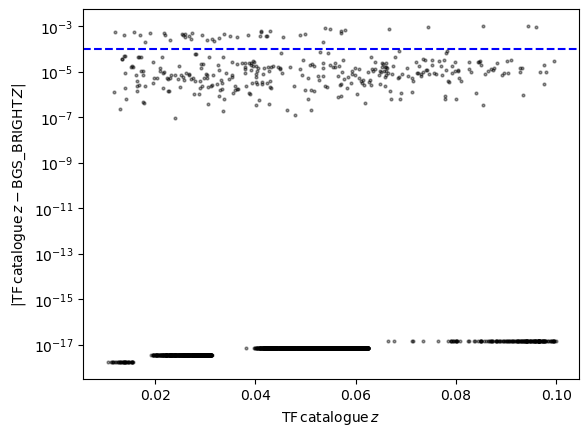

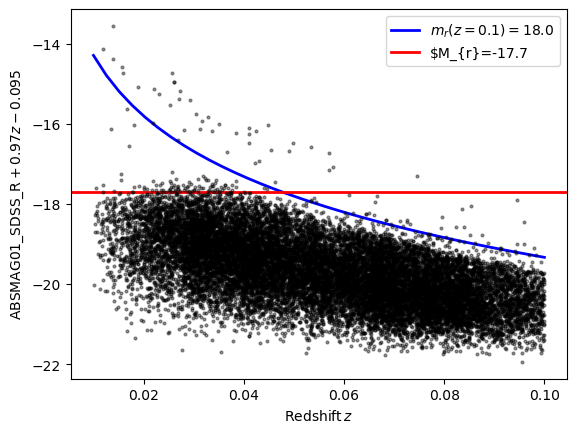

In [5]:
# There's some small differences between the various redshifts in the cross-match. Needs checking....
plt.errorbar(data_BRIGHT["Z"], np.fabs(data_BRIGHT["Z"] - data_BRIGHT["Z_DESI"]), color='k', ls="None", marker='o', ms=2, alpha=0.4)
plt.xlabel(r'$\mathrm{TF\,catalogue}\,z$')
plt.ylabel(r'|$\mathrm{TF\,catalogue}\,z - \mathrm{BGS\_BRIGHT}\,Z$|')
plt.axhline(y=1.0e-4, c='b', ls='--') 
plt.yscale('log')
plt.show();

# Plot the magnitude against redshift for our FP sample
cosmo = FlatLambdaCDM(H0=100,Om0=0.3151)
distmax = cosmo.comoving_distance(zmax).value

redbins = np.linspace(zmin, zmax, nzbin)
magline = 18.0 - 5.0*np.log10(cosmo.comoving_distance(redbins).value) - 25.0 - 0.97*redbins + 0.095
cluslumdat = data_BRIGHT["ABSMAG01_SDSS_R"] + 0.97*data_BRIGHT["Z"] - 0.095
plt.errorbar(data_BRIGHT["Z"], cluslumdat, color='k', ls="None", marker='o', ms=2, alpha=0.4)
plt.plot(redbins, magline, color='b', ls='-', lw=2.0, label="$m_{r}(z=0.1)=18.0$")
plt.axhline(y=-17.7, color='r', ls='-', lw=2.0, label="$M_{r}=-17.7")
plt.xlabel(r'$\mathrm{Redshift}\,z$')
plt.ylabel(r'$\mathrm{ABSMAG01\_SDSS\_R}+0.97z-0.095$')
plt.legend()
plt.show();

In [6]:
# There are some outliers when comparing the redshifts, arising from the difference between the BGS clustering z, and the average of those with delta_chi2 > 25 within 0.1 R_e used in constructing the TF sample.
# It's not clear which to use, as I would have thought the average to be better, but it could be that we hit something else in the background. So let's just remove the outliers, with a threshold of 1.0e-4 absolute difference
print(len(data_BRIGHT))
data_BRIGHT = data_BRIGHT.drop(data_BRIGHT[np.fabs(data_BRIGHT["Z"]-data_BRIGHT["Z_DESI"]) > 1.0e-4].index)
print(len(data_BRIGHT))

19385
19340


Index(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'], dtype='str')


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_599666/657674163.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.plot((zlims[:-1]+zlims[1:])/2.0, nzdat/volume, color='k', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,No\,M_{r}\,cut}$")
/tmp/ipykernel_599666/657674163.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.plot((zlims[:-1]+zlims[1:])/2.0, nzclusdat/volume, color='r', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,M_{r}<=-17.7}$")
/tmp/ipykernel_599666/657674163.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.plot((zlims[:-1]+zlims[1:])/2.0, nztf/volume, color='b', ls='-', lw=1.5, label="$\mathrm{PV\,catalogue}$")


Index(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'], dtype='str')


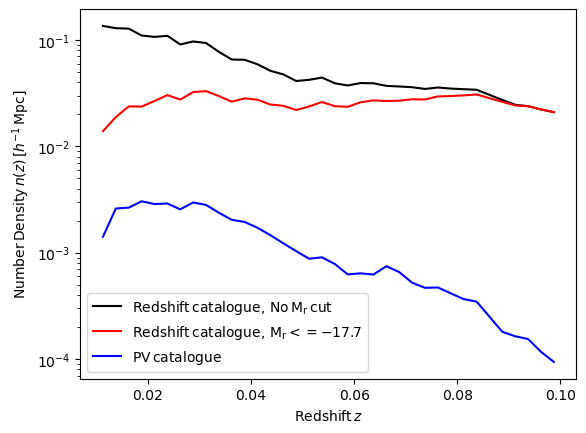

/tmp/ipykernel_599666/657674163.py:27: RuntimeWarning: invalid value encountered in divide
  completeness = np.where(BGS_count > 0, (TF_count/BGS_count)/np.amax(TF_count[BGS_count > 0]/BGS_count[BGS_count > 0]), 0)


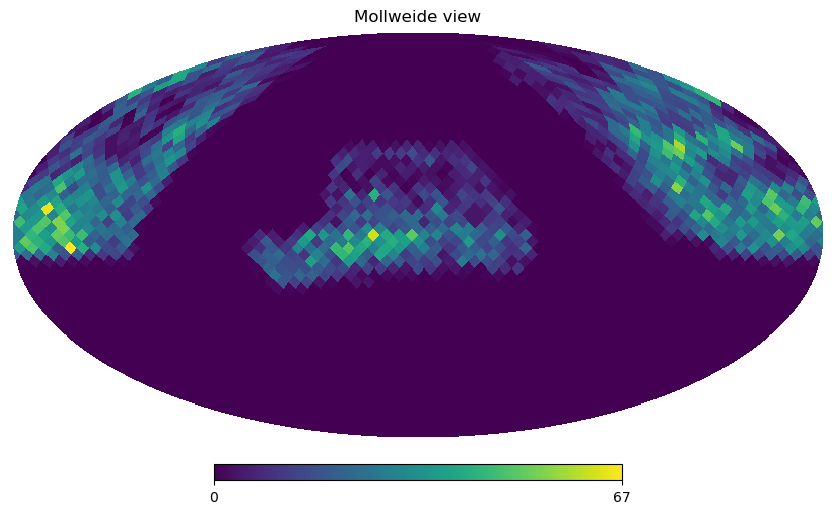

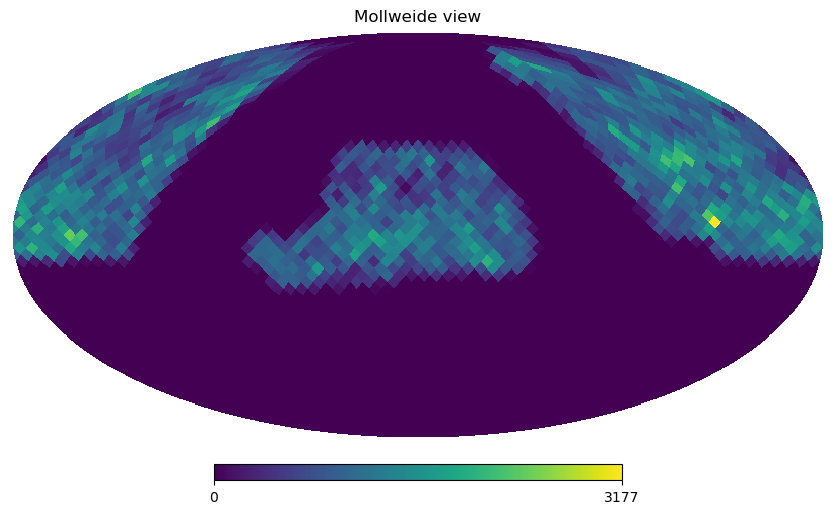

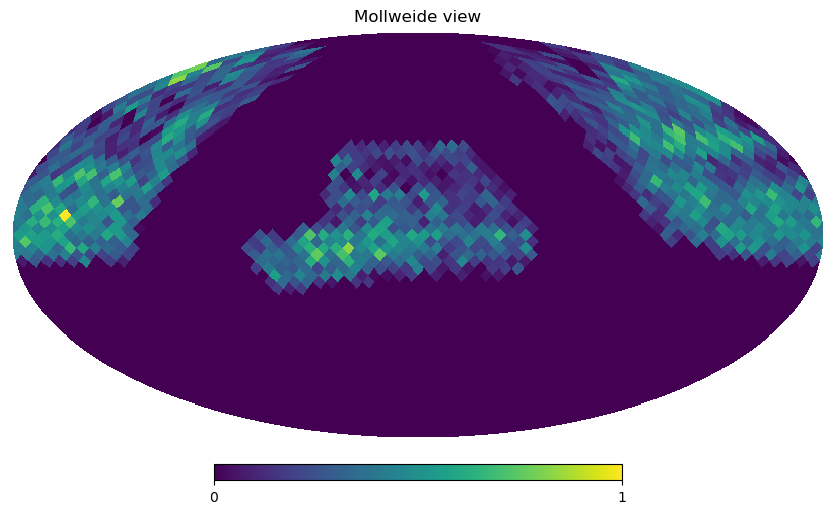

In [7]:
# Read in the forPV clustering data (has a 17.7 magnitude limit)
BGS_BRIGHT_clustering_forPV_data = Table.read("/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_data.fits").to_pandas()
print(BGS_BRIGHT_clustering_forPV_data.keys())

# Read in the forPV clustering randoms (has a 17.7 magnitude limit)
BGS_BRIGHT_clustering_forPV_ran = Table.read("/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_random.fits").to_pandas()
print(BGS_BRIGHT_clustering_forPV_ran.keys())

# Plot the number densities of the redshift sample
nwdat, nwtf = np.sum(BGS_BRIGHT_clustering_forPV_data["WEIGHT"]), np.sum(data_BRIGHT["WEIGHT"])
nzdat,zlims = np.histogram(BGS_BRIGHT_clustering["Z"],bins=nzbin,range=[zmin,zmax], weights=BGS_BRIGHT_clustering["WEIGHT"])
nzclusdat,zlims = np.histogram(BGS_BRIGHT_clustering_forPV_data["Z"],bins=nzbin,range=[zmin,zmax], weights=BGS_BRIGHT_clustering_forPV_data["WEIGHT"])
nztf,zlims = np.histogram(data_BRIGHT["Z"],bins=nzbin,range=[zmin,zmax], weights=data_BRIGHT["WEIGHT"])
volume = survey_area/3.0 * (cosmo.comoving_distance(zlims[1:]).value**3 - cosmo.comoving_distance(zlims[:-1]).value**3)

plt.plot((zlims[:-1]+zlims[1:])/2.0, nzdat/volume, color='k', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,No\,M_{r}\,cut}$")
plt.plot((zlims[:-1]+zlims[1:])/2.0, nzclusdat/volume, color='r', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,M_{r}<=-17.7}$")
plt.plot((zlims[:-1]+zlims[1:])/2.0, nztf/volume, color='b', ls='-', lw=1.5, label="$\mathrm{PV\,catalogue}$")
plt.yscale('log')
plt.xlabel(r'$\mathrm{Redshift}\,z$')
plt.ylabel(r'$\mathrm{Number\,Density}\,n(z)\,[h^{-1}\,\mathrm{Mpc}]$')
plt.legend();
plt.show();

TF_count = map_count(data_BRIGHT["RA_y"], data_BRIGHT["DEC_y"], nside=nside)
BGS_count = map_count(BGS_BRIGHT_clustering["RA"], BGS_BRIGHT_clustering["DEC"], nside=nside)
completeness = np.where(BGS_count > 0, (TF_count/BGS_count)/np.amax(TF_count[BGS_count > 0]/BGS_count[BGS_count > 0]), 0)
hp.mollview(TF_count, nest=True)
hp.mollview(BGS_count, nest=True)
hp.mollview(completeness, nest=True)

In [8]:
# Now that the catalogue looks good, let's copy Chris's code for making the redshift clustering catalogue to also make a FP clustering catalogue with some randoms

# Read in clustering random catalogue
print('\nReading in clustering random catalogues...')
clusrasran,clusdecran,clusredran,clusweiran,clusnxran,clusntileran = np.array([]),np.array([]),np.array([]),np.array([]),np.array([]),np.array([])
for iset in range(rsets):
  bgsclusranfile = 'BGS_BRIGHT_NGC_' + str(iset) + '_clustering.ran.fits'
  print(stem+bgsclusranfile)
  hdulist = fits.open(stem+bgsclusranfile)
  table = hdulist[1].data
  clusrasran1 = table.field('RA')
  clusdecran1 = table.field('DEC')
  clusredran1 = table.field('Z')
  clusweiran1 = table.field('WEIGHT')
  clusnxran1 = table.field('NX')
  clusntileran1 = table.field('NTILE')
  hdulist.close()
  bgsclusranfile = 'BGS_BRIGHT_SGC_' + str(iset) + '_clustering.ran.fits'
  print(stem+bgsclusranfile)
  hdulist = fits.open(stem+bgsclusranfile)
  table = hdulist[1].data
  clusrasran2 = table.field('RA')
  clusdecran2 = table.field('DEC')
  clusredran2 = table.field('Z')
  clusweiran2 = table.field('WEIGHT')
  clusnxran2 = table.field('NX')
  clusntileran2 = table.field('NTILE')
  hdulist.close()
# Cut random catalogues to redshift range
  cut = (clusredran1 >= zmin) & (clusredran1 <= zmax)
  clusrasran1,clusdecran1,clusredran1,clusweiran1,clusnxran1,clusntileran1 = clusrasran1[cut],clusdecran1[cut],clusredran1[cut],clusweiran1[cut],clusnxran1[cut],clusntileran1[cut]
  cut = (clusredran2 >= zmin) & (clusredran2 <= zmax)
  clusrasran2,clusdecran2,clusredran2,clusweiran2,clusnxran2,clusntileran2 = clusrasran2[cut],clusdecran2[cut],clusredran2[cut],clusweiran2[cut],clusnxran2[cut],clusntileran2[cut]
# Concatenate into master random dataset
  clusrasran = np.concatenate((clusrasran,clusrasran1,clusrasran2))
  clusdecran = np.concatenate((clusdecran,clusdecran1,clusdecran2))
  clusredran = np.concatenate((clusredran,clusredran1,clusredran2))
  clusweiran = np.concatenate((clusweiran,clusweiran1,clusweiran2))
  clusnxran = np.concatenate((clusnxran,clusnxran1,clusnxran2))
  clusntileran = np.concatenate((clusntileran,clusntileran1,clusntileran2))
print(len(clusrasran),'randoms with',zmin,'< z <',zmax)

# Randomize the order of the random sources
print('\nRandomizing order of randoms...')
cut = np.arange(len(clusrasran))
np.random.shuffle(cut)
clusrasran,clusdecran,clusredran,clusweiran,clusnxran,clusntileran = clusrasran[cut],clusdecran[cut],clusredran[cut],clusweiran[cut],clusnxran[cut],clusntileran[cut]

# Sub-sampling fraction of density-field catalogue versus full randoms
print('\nSub-sampling random catalogue...')
subfracz = nzclusdat.astype(float)/nzdat.astype(float)
# Normalise to 1.0 to maximize size of random catalogue
subfracz /= np.amax(subfracz)
print('Sub-sampling fraction =',subfracz)

# Sub-sampling fraction of TF catalogue versus full randoms
print('\nSub-sampling random catalogue...')
subfracztf = nztf.astype(float)/nzdat.astype(float)
# Normalise to 1.0 to maximize size of random catalogue
subfracztf /= np.amax(subfracztf)
print('Sub-sampling fraction =',subfracztf)


Reading in clustering random catalogues...
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_0_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_0_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_1_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_1_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_2_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_2_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_3_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_3_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_4_clus

In [9]:
# Box enclosing data
distmax = cosmo.comoving_distance(zmax).value
nx,ny,nz = ngrid,ngrid,ngrid
lx,ly,lz = 2.*distmax,2.*distmax,2.*distmax
dx,dy,dz = lx/nx,ly/ny,lz/nz
x0,y0,z0 = distmax,distmax,distmax
dvol = dx*dy*dz

# Apply redshift sub-sampling to random catalogue
# This assumes luminosity distribution of data is even across the sky
izs = np.digitize(clusredran,np.linspace(zmin,zmax,nzbin+1)) - 1
clusnxran *= subfracz[izs]
cut = subfracz[izs] > np.random.uniform(size=len(clusredran))
clusrasrandens,clusdecrandens,clusredrandens,clusweirandens,clusnxrandens = clusrasran[cut],clusdecran[cut],clusredran[cut],clusweiran[cut],clusnxran[cut]
print(len(clusrasrandens),'density randoms after sub-sampling')

# Construct 3D number density from random catalogues for density
dist = cosmo.comoving_distance(clusredrandens).value
clusxran = dist*np.cos(np.radians(clusdecrandens))*np.cos(np.radians(clusrasrandens))
clusyran = dist*np.cos(np.radians(clusdecrandens))*np.sin(np.radians(clusrasrandens))
cluszran = dist*np.sin(np.radians(clusdecrandens))
winweigrid,edges = np.histogramdd(np.vstack([clusxran+x0,clusyran+y0,cluszran+z0]).transpose(),bins=(nx,ny,nz),range=((0.,lx),(0.,ly),(0.,lz)),density=False,weights=clusweirandens)
ndensweigrid = (nwdat/dvol)*(winweigrid/np.sum(winweigrid))

58066567 density randoms after sub-sampling


80333294 25883540


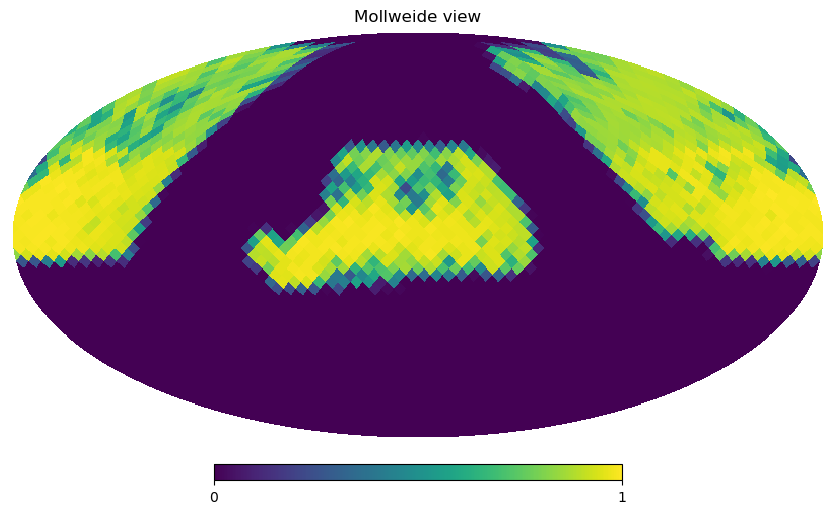

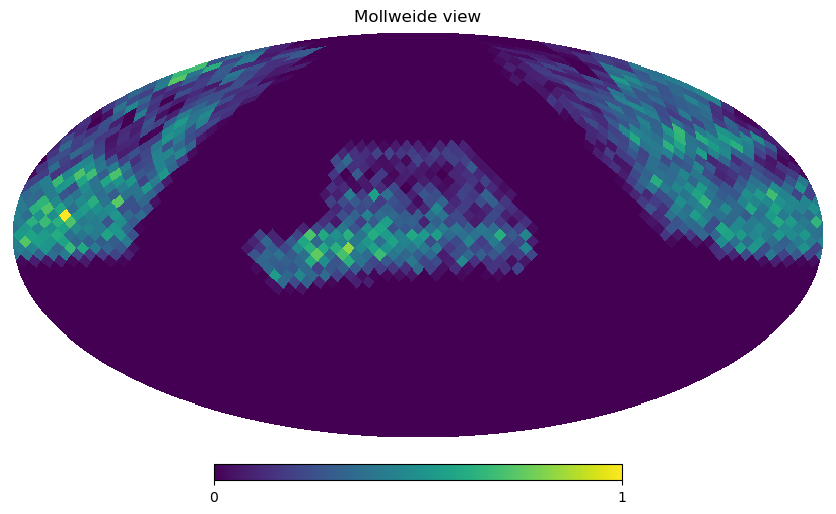

In [10]:
# Subsample the TF randoms using a healpix mask to better match the on-sky distribution of TF data.
theta, phi = radec2thphi(clusrasran, clusdecran)
rand_pix = hp.ang2pix(nside,theta,phi,nest=True)
rand_comp = completeness[rand_pix]
mask_cut = rand_comp > np.random.uniform(size=len(clusredran))
count = map_count(clusrasran, clusdecran, nside=nside)
hp.mollview(count/np.amax(count), nest=True)
count = map_count(clusrasran[mask_cut], clusdecran[mask_cut], nside=nside)
hp.mollview(count/np.amax(count), nest=True)
print(len(clusrasran), len(clusrasran[mask_cut]))

In [11]:
# Apply TF redshift sub-sampling to random catalogue
# This assumes luminosity distribution of data is even across the sky
izs = np.digitize(clusredran,np.linspace(zmin,zmax,nzbin+1)) - 1
clusnxran *= subfracztf[izs]
cut = (subfracztf[izs] > np.random.uniform(size=len(clusredran))) & mask_cut
clusrasran,clusdecran,clusredran,clusweiran,clusnxran = clusrasran[cut],clusdecran[cut],clusredran[cut],clusweiran[cut],clusnxran[cut]
print(len(clusrasran),'PV randoms after sub-sampling')

# Construct 3D number density from random catalogues for PV
dist = cosmo.comoving_distance(clusredran).value
clusxran = dist*np.cos(np.radians(clusdecran))*np.cos(np.radians(clusrasran))
clusyran = dist*np.cos(np.radians(clusdecran))*np.sin(np.radians(clusrasran))
cluszran = dist*np.sin(np.radians(clusdecran))
winweigrid,edges = np.histogramdd(np.vstack([clusxran+x0,clusyran+y0,cluszran+z0]).transpose(),bins=(nx,ny,nz),range=((0.,lx),(0.,ly),(0.,lz)),density=False,weights=clusweiran)
npvweigrid = (nwtf/dvol)*(winweigrid/np.sum(winweigrid))

# Sample both the density field and PV field number density at PV galaxy and random positions
xlims = np.linspace(0.,lx,nx+1) - x0
ylims = np.linspace(0.,ly,ny+1) - y0
zlims = np.linspace(0.,lz,nz+1) - z0
dist = cosmo.comoving_distance(data_BRIGHT["Z"]).value
clusxdat = dist*np.cos(np.radians(data_BRIGHT["DEC_y"]))*np.cos(np.radians(data_BRIGHT["RA_y"]))
clusydat = dist*np.cos(np.radians(data_BRIGHT["DEC_y"]))*np.sin(np.radians(data_BRIGHT["RA_y"]))
cluszdat = dist*np.sin(np.radians(data_BRIGHT["DEC_y"]))
ix = np.digitize(clusxdat,xlims) - 1
iy = np.digitize(clusydat,ylims) - 1
iz = np.digitize(cluszdat,zlims) - 1
print(np.amin(ix), np.amax(ix), np.amin(iy), np.amax(iy), np.amin(iy), np.amax(iy)) 
clusndensdat = ndensweigrid[ix,iy,iz]
clusnpvdat = npvweigrid[ix,iy,iz]
ix = np.digitize(clusxran,xlims) - 1
iy = np.digitize(clusyran,ylims) - 1
iz = np.digitize(cluszran,zlims) - 1
print(np.amin(ix), np.amax(ix), np.amin(iy), np.amax(iy), np.amin(iy), np.amax(iy)) 
clusndensran = ndensweigrid[ix,iy,iz]
clusnpvran = npvweigrid[ix,iy,iz]

print(np.amin(clusndensdat), np.amin(clusndensran))
print(np.amin(clusnpvdat), np.amin(clusnpvran), np.amax(clusnpvdat), np.amax(clusnpvran))

print('\nNumber density from grid:')
print('Data dens =',np.mean(clusndensdat),'+/-',np.std(clusndensdat))
print('Random dens =',np.mean(clusndensran),'+/-',np.std(clusndensran))
print('Data pv =',np.mean(clusnpvdat),'+/-',np.std(clusnpvdat))
print('Random pv =',np.mean(clusnpvran),'+/-',np.std(clusnpvran))

13278814 PV randoms after sub-sampling
0 127 4 121 4 121
0 127 2 125 2 125
0.0005994865636666872 0.0
0.0 6.707869528943383e-06 0.008762797422089463 0.008899527287916013

Number density from grid:
Data dens = 0.025418965666735096 +/- 0.005202868357309641
Random dens = 0.02498765807490053 +/- 0.005581461571669672
Data pv = 0.0013723331590110126 +/- 0.00123499982988698
Random pv = 0.0013680741118230072 +/- 0.0012520454436319173


In [12]:
# For the PV clustering the FKP-style weights also have a <v^2> term, so we need a value for this for each random point. Let's generate one by assigning an error based on the nearest real galaxy
# This is now batched to avoid memory issues with the large query of the KDTree!!
n_ran = len(clusxran)
batch_size = 5000000 
tree_data = KDTree(np.c_[clusxdat, clusydat, cluszdat])

# Pre-allocate result arrays
clusranmuerr = np.empty(n_ran)

# Use .values for the lookup to avoid Pandas overhead inside the loop
err_orig_raw = data_BRIGHT["MU_TF_ERR"].values

# Batch Loop
for start in range(0, n_ran, batch_size):
    end = min(start + batch_size, n_ran)
    
    # Query current batch
    batch_coords = np.c_[clusxran[start:end], clusyran[start:end], cluszran[start:end]]
    nn = tree_data.query(batch_coords, return_distance=False, dualtree=True)
    indices = nn[:, 0]

    # Assign results using the pre-calculated factor and indexed values
    clusranmuerr[start:end] = err_orig_raw[indices]
    
    print(f"Processed through {end} / {n_ran}")

print("Batching complete.")

clusranlogdisterr = clusranmuerr / 5.0

clusredrancmb = perform_corr(clusredran, clusrasran, clusdecran)
H_vals = cosmo.H(clusredrancmb).value
D_vals = cosmo.comoving_distance(clusredrancmb).value
global_factor = (LightSpeed * np.log(10.0)) / ((LightSpeed * (1.0 + clusredrancmb) / (H_vals * D_vals)) - 1.0)

clusranpverr = global_factor * clusranlogdisterr

Processed through 5000000 / 13278814
Processed through 10000000 / 13278814
Processed through 13278814 / 13278814
Batching complete.


In [13]:
# Output the clustering files
print(np.amin(data_BRIGHT["Z"]))

# Output data catalogue
col1 = fits.Column(name='TARGETID',format='K',array=data_BRIGHT["TARGETID"])
col2 = fits.Column(name='SGA_ID',format='K',array=data_BRIGHT["SGA_ID"])
col3 = fits.Column(name='RA',format='D',array=data_BRIGHT["RA_y"])
col4 = fits.Column(name='DEC',format='D',array=data_BRIGHT["DEC_y"])
col5 = fits.Column(name='Z',format='D',array=data_BRIGHT["Z"])
col6 = fits.Column(name='ZCMB',format='D',array=perform_corr(data_BRIGHT["Z"], data_BRIGHT["RA_y"], data_BRIGHT["DEC_y"]))
col7 = fits.Column(name='WEIGHT',format='D',array=data_BRIGHT["WEIGHT"])
col8 = fits.Column(name='NPV',format='D',array=clusnpvdat)
col9 = fits.Column(name='NDENS',format='D',array=clusndensdat)
col10 = fits.Column(name='MU',format='D',array=data_BRIGHT["MU_TF"])
col11 = fits.Column(name='MU_ERR',format='D',array=data_BRIGHT["MU_TF_ERR"])
hdulist = fits.BinTableHDU.from_columns([col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11])
outfile = f'Y3/TF_clustering_data_v{version}.fits'
print('\nWriting out data catalogue...')
print(outfile)
hdulist.writeto(outfile, overwrite=True)

np.savetxt(f'/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/TF_clustering_data_v{version}.csv', 
           np.c_[data_BRIGHT["TARGETID"].to_numpy(), data_BRIGHT["SGA_ID"].to_numpy(), data_BRIGHT["RA_y"].to_numpy(), data_BRIGHT["DEC_y"].to_numpy(), data_BRIGHT["Z"].to_numpy(), perform_corr(data_BRIGHT["Z"], data_BRIGHT["RA_y"], data_BRIGHT["DEC_y"]), data_BRIGHT["WEIGHT"].to_numpy(), clusnpvdat, clusndensdat, data_BRIGHT["MU_TF"].to_numpy(), data_BRIGHT["MU_TF_ERR"].to_numpy()],
           header="TARGETID,SGA_ID,RA,DEC,Z,ZCMB,WEIGHT,NPV,NDENS,MU,MU_ERR")

# Sub-sample random catalogue
cut = np.random.choice(len(clusrasran),200*len(data_BRIGHT),replace=False)
clusrasran,clusdecran,clusredran,clusredrancmb,clusweiran,clusnpvran,clusndensran,clusranmuerr,clusranlogdisterr,clusranpverr = clusrasran[cut],clusdecran[cut],clusredran[cut],clusredrancmb[cut],clusweiran[cut],clusnpvran[cut],clusndensran[cut],clusranmuerr[cut],clusranlogdisterr[cut],clusranpverr[cut]
print('\nRandom catalogue cut to',len(clusrasran),'sources')

# Output random catalogue
col1 = fits.Column(name='RA',format='D',array=clusrasran)
col2 = fits.Column(name='DEC',format='D',array=clusdecran)
col3 = fits.Column(name='Z',format='D',array=clusredran)
col4 = fits.Column(name='ZCMB',format='D',array=clusredrancmb)
col5 = fits.Column(name='WEIGHT',format='D',array=clusweiran)
col6 = fits.Column(name='NPV',format='D',array=clusnpvran)
col7 = fits.Column(name='NDENS',format='D',array=clusndensran)
col8 = fits.Column(name='MU_ERR',format='D',array=clusranmuerr)
col9 = fits.Column(name='LOGDIST_ERR',format='D',array=clusranlogdisterr)
col10 = fits.Column(name='PV_ERR',format='D',array=clusranpverr)
hdulist = fits.BinTableHDU.from_columns([col1,col2,col3,col4,col5,col6,col7,col8,col9,col10])
outfile = f'Y3/TF_clustering_random200_v{version}.fits'
print('\nWriting out random catalogue...')
print(outfile)
hdulist.writeto(outfile, overwrite=True)

np.savetxt(f'/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/TF_clustering_random200_v{version}.csv', 
           np.c_[clusrasran, clusdecran, clusredran, clusredrancmb, clusweiran, clusnpvran, clusndensran, clusranmuerr, clusranlogdisterr, clusranpverr],
           header="RA,DEC,Z,ZCMB,WEIGHT,NPV,NDENS,MU_ERR,LOGDIST_ERR,PV_ERR")

# Sub-sample random catalogue
cut = np.random.choice(len(clusrasran),20*len(data_BRIGHT),replace=False)
clusrasran,clusdecran,clusredran,clusredrancmb,clusweiran,clusnpvran,clusndensran,clusranmuerr,clusranlogdisterr,clusranpverr = clusrasran[cut],clusdecran[cut],clusredran[cut],clusredrancmb[cut],clusweiran[cut],clusnpvran[cut],clusndensran[cut],clusranmuerr[cut],clusranlogdisterr[cut],clusranpverr[cut]
print('\nRandom catalogue cut to',len(clusrasran),'sources')

# Output random catalogue
col1 = fits.Column(name='RA',format='D',array=clusrasran)
col2 = fits.Column(name='DEC',format='D',array=clusdecran)
col3 = fits.Column(name='Z',format='D',array=clusredran)
col4 = fits.Column(name='ZCMB',format='D',array=clusredrancmb)
col5 = fits.Column(name='WEIGHT',format='D',array=clusweiran)
col6 = fits.Column(name='NPV',format='D',array=clusnpvran)
col7 = fits.Column(name='NDENS',format='D',array=clusndensran)
col8 = fits.Column(name='MU_ERR',format='D',array=clusranmuerr)
col9 = fits.Column(name='LOGDIST_ERR',format='D',array=clusranlogdisterr)
col10 = fits.Column(name='PV_ERR',format='D',array=clusranpverr)
hdulist = fits.BinTableHDU.from_columns([col1,col2,col3,col4,col5,col6,col7,col8,col9,col10])
outfile = f'Y3/TF_clustering_random20_v{version}.fits'
print('\nWriting out random catalogue...')
print(outfile)
hdulist.writeto(outfile, overwrite=True)

np.savetxt(f'/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/TF_clustering_random20_v{version}.csv', 
           np.c_[clusrasran, clusdecran, clusredran, clusredrancmb, clusweiran, clusnpvran, clusndensran, clusranmuerr, clusranlogdisterr, clusranpverr],
           header="RA,DEC,Z,ZCMB,WEIGHT,NPV,NDENS,MU_ERR,LOGDIST_ERR,PV_ERR")

0.010072103578012557

Writing out data catalogue...
Y3/TF_clustering_data_v4.fits

Random catalogue cut to 3868000 sources

Writing out random catalogue...
Y3/TF_clustering_random200_v4.fits

Random catalogue cut to 386800 sources

Writing out random catalogue...
Y3/TF_clustering_random20_v4.fits
